# Homework 2 Coding Portion

In [61]:
# Make sure to use the .venv311 kernel for this

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

Text(0.5, 1.0, 'Scatter plot of thalach vs oldpeak coloured by target')

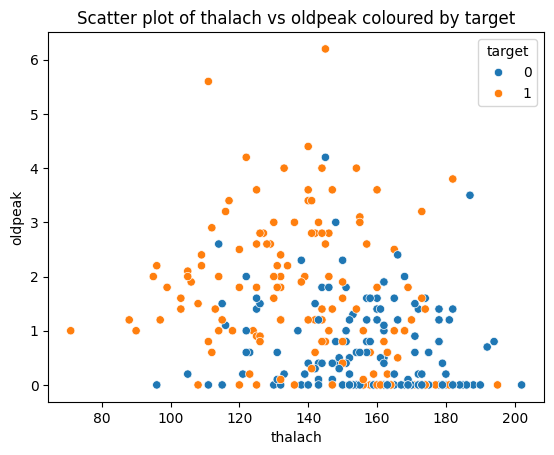

In [62]:
# 4(a)(i)
# create a scatter plot of the full dataset coloured by label
df = pd.read_csv('heart_disease.csv')
df = df[['thalach', 'oldpeak', 'target']]
sns.scatterplot(data=df, x='thalach', y='oldpeak', hue='target')
plt.title('Scatter plot of thalach vs oldpeak coloured by target')

The data is not linearly separable by eye. 
Much of the 2D region is where the two features visibly overlap; it is not easy to linearly separate the data by eye.

In [63]:
# 4(a)(ii)
# split 80/20 using np.random.seed(42)
np.random.seed(42)
msk = np.random.rand(len(df)) < 0.8
train = df[msk].copy() # mask to get the training set

# standardize both features to zero mean and unit variance using the training set statistics
train_mean = train[['thalach', 'oldpeak']].mean()
train_std = train[['thalach', 'oldpeak']].std()
train[['thalach', 'oldpeak']] = (train[['thalach', 'oldpeak']] - train_mean) / train_std

# apply the same mu and sigma to the test set
test = df[~msk].copy() # unmask to get the test set
test[['thalach', 'oldpeak']] = (test[['thalach', 'oldpeak']] - train_mean) / train_std

It would be incorrect to compute mu and sigma using the combined train + test data because we don't want to allow the test data to affect the training of the model. 
This normalization uses only the training mu and sigma because allowing the train data to affect the learning is called "data leakage."

Text(0.5, 1.0, 'SVM decision boundary with support vectors highlighted')

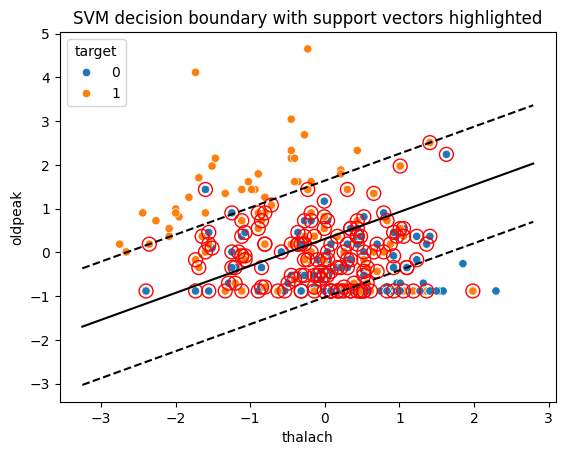

In [64]:
# 4(b)(i)
params = SVC(kernel='linear', C=1).fit(train[['thalach', 'oldpeak']], train['target'])

# plot the decision boundary
w = params.coef_[0]
b = params.intercept_[0]
x = np.linspace(train['thalach'].min() - 0.5, train['thalach'].max() + 0.5, 100)
y = -(w[0] * x + b) / w[1]
sns.scatterplot(data=train, x='thalach', y='oldpeak', hue='target')

# print the line and the margin lines at distance 1 from the line
plt.plot(x, y, color='black')
plt.plot(x, -(w[0] * x + b - 1) / w[1], color='black', linestyle='dashed')
plt.plot(x, -(w[0] * x + b + 1) / w[1], color='black', linestyle='dashed')
plt.title('SVM decision boundary with linear kernel')

# highlight the support vectors
support_vectors = params.support_vectors_
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=100, facecolors='none', edgecolors='red')
plt.title('SVM decision boundary with support vectors highlighted')

In [65]:
# 4(b)(ii)
# report training and test accuracy
train_acc = params.score(train[['thalach', 'oldpeak']], train['target'])
test_acc = params.score(test[['thalach', 'oldpeak']], test['target'])
print(f'Training accuracy: {train_acc:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

Training accuracy: 0.7208
Test accuracy: 0.7460


In [66]:
# 4(c)(i)
d = [2, 3, 5]
for degree in d:
    params = SVC(kernel='poly', degree=degree, C=1).fit(train[['thalach', 'oldpeak']], train['target'])
    
    # report the training and test accuracy for this degree
    train_acc = params.score(train[['thalach', 'oldpeak']], train['target'])
    test_acc = params.score(test[['thalach', 'oldpeak']], test['target'])
    print(f'Degree {degree}: Training accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}')

Degree 2: Training accuracy: 0.6792, Test accuracy: 0.6984
Degree 3: Training accuracy: 0.6917, Test accuracy: 0.7460
Degree 5: Training accuracy: 0.6917, Test accuracy: 0.7460


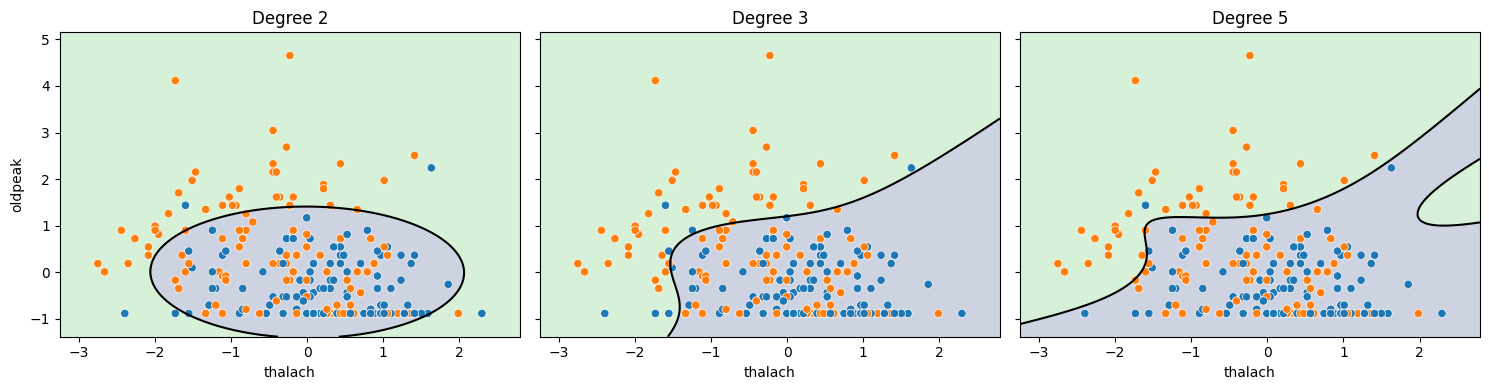

In [67]:
# 4(c)(ii)
degrees = [2, 3, 5]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

x_min, x_max = train['thalach'].min() - 0.5, train['thalach'].max() + 0.5
y_min, y_max = train['oldpeak'].min() - 0.5, train['oldpeak'].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=['thalach', 'oldpeak']
)

for ax, degree in zip(axes, degrees):
    model = SVC(kernel='poly', degree=degree, C=1)
    model.fit(train[['thalach', 'oldpeak']], train['target'])

    Z = model.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z > 0, alpha=0.25)
    ax.contour(xx, yy, Z, levels=[0], colors='black')

    sns.scatterplot(
        data=train,
        x='thalach',
        y='oldpeak',
        hue='target',
        ax=ax
    )

    ax.set_title(f'Degree {degree}')
    ax.legend_.remove()

plt.tight_layout()
plt.show()


The boundary shape becomes more sharp as the degree gets higher. Also, it looks like it starts actually taking into account points that are not within the boundary versus points that are not within the boundary, as with the degree-5 polynomial, there is a sharp bump that splits a lot of blue points from a lot of orange points. 

It is at degree 5 that overfitting starts to look somewhat visually apparent because there are some remote points where the boundary is shaped just so that it excludes those points from being inside. There is also an extra region carved out on the right side, likely an artifact from being a fifth-degree polynomial. 

In [68]:
# 4(d)(i)
gamma = [0.1, 1, 10, 100]
for g in gamma:
    model = SVC(kernel='rbf', gamma=g, C=1).fit(train[['thalach', 'oldpeak']], train['target'])

    # report training and testing accuracy for this gamma
    train_acc = model.score(train[['thalach', 'oldpeak']], train['target'])
    test_acc = model.score(test[['thalach', 'oldpeak']], test['target'])
    print(f'Gamma {g}: Training accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}')

Gamma 0.1: Training accuracy: 0.7208, Test accuracy: 0.7778
Gamma 1: Training accuracy: 0.7375, Test accuracy: 0.7937
Gamma 10: Training accuracy: 0.8000, Test accuracy: 0.8095
Gamma 100: Training accuracy: 0.9208, Test accuracy: 0.6667


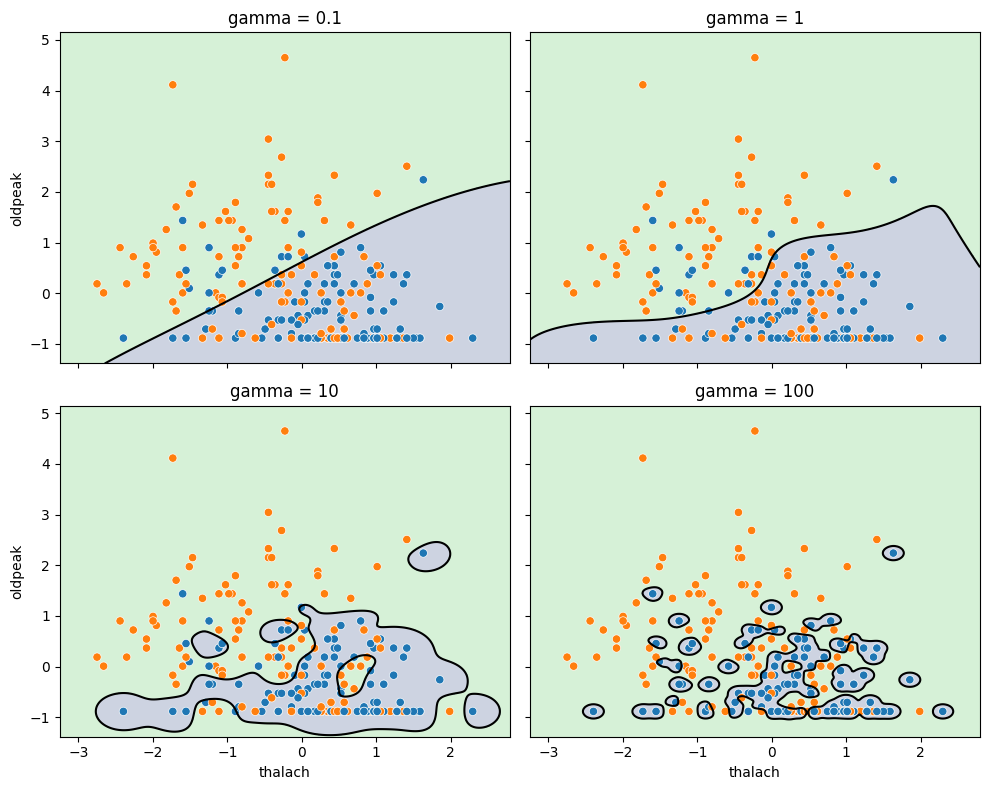

In [69]:
# 4(d)(ii)
gammas = [0.1, 1, 10, 100]
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

x_min, x_max = train['thalach'].min() - 0.5, train['thalach'].max() + 0.5
y_min, y_max = train['oldpeak'].min() - 0.5, train['oldpeak'].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=['thalach', 'oldpeak']
)

for ax, gamma in zip(axes, gammas):
    model = SVC(kernel='rbf', gamma=gamma, C=1)
    model.fit(train[['thalach', 'oldpeak']], train['target'])

    Z = model.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z > 0, alpha=0.25)
    ax.contour(xx, yy, Z, levels=[0], colors='black')

    sns.scatterplot(
        data=train,
        x='thalach',
        y='oldpeak',
        hue='target',
        ax=ax
    )

    ax.set_title(f'gamma = {gamma}')
    ax.legend_.remove()

plt.tight_layout()
plt.show()


Gamma = 10 has the best test accuracy (at 0.8095).

Gamma = 100 is where the model has clearly overfit because the test accuracy goes down to 0.6667, which is much lower than the other gamma values.

Text(0.5, 1.0, 'SVM vs Logistic Regression decision boundaries')

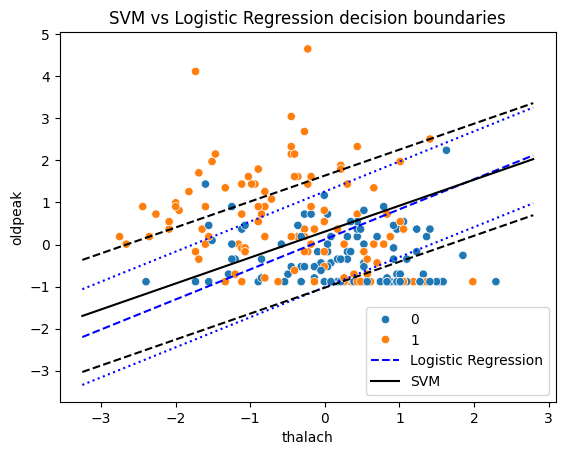

In [70]:
# 4(e)(i)

params = SVC(kernel='linear', C=1).fit(train[['thalach', 'oldpeak']], train['target'])

# plot the decision boundary
w = params.coef_[0]
b = params.intercept_[0]
x = np.linspace(train['thalach'].min() - 0.5, train['thalach'].max() + 0.5, 100)
y = -(w[0] * x + b) / w[1]
sns.scatterplot(data=train, x='thalach', y='oldpeak', hue='target')

# fit LogisticRegression on the same two features and overlay its decision boundary
logreg = LogisticRegression().fit(train[['thalach', 'oldpeak']], train['target'])

# plot the logistic regression decision boundary
coef = logreg.coef_[0]
intercept = logreg.intercept_[0]
y_logreg = -(coef[0] * x + intercept) / coef[1]
plt.plot(x, y_logreg, color='blue', linestyle='dashed', label='Logistic Regression')
# print the margin lines too
plt.plot(x, -(coef[0] * x + intercept - 1) / coef[1], color='blue', linestyle='dotted')
plt.plot(x, -(coef[0] * x + intercept + 1) / coef[1], color='blue', linestyle='dotted')

# print the line and the margin lines at distance 1 from the line
plt.plot(x, y, color='black', label='SVM')
plt.plot(x, -(w[0] * x + b - 1) / w[1], color='black', linestyle='dashed')
plt.plot(x, -(w[0] * x + b + 1) / w[1], color='black', linestyle='dashed')

plt.legend()
plt.title('SVM vs Logistic Regression decision boundaries')

They are both straight lines. 

They do not coincide exactly, and they can differ because they try to optimize different objective functions. The logistic regression tries to optimize an objective function that uses a sigmoid shape while the hinge loss simply cancels any contribution from negative m values. This is why there is a slight difference (negative m values do not have a large effect on the result after optimization).

In [71]:
# 4(e)(ii)
model = SVC(kernel='rbf', gamma=1, C=1).fit(train[['thalach', 'oldpeak']], train['target'])

# pick (10, 10) and compute h(x_star) for this point
x_star = np.array([[10, 10]])
alpha_n_y_n = model.dual_coef_
x_n = model.support_vectors_
K_xn_xstar = sklearn.metrics.pairwise.rbf_kernel(x_n, x_star, gamma=1).flatten()
h_x_star = np.sum(alpha_n_y_n * K_xn_xstar) + model.intercept_[0]
print(f'h(x_star) for x_star = (10, 10) is {h_x_star:.4f}')

h(x_star) for x_star = (10, 10) is 0.2683


The magnitude is close to the intercept.

This means that the confidence of the classifier on points that are very far from anything it has seen is very low, as the portion of the h(x_star) equation that uses x_n and y_n (everything except the intercept) goes to zero. Therefore, the classifier is only using the intercept and not really using the data to make this classification.

In [72]:
# 5(a)(i)
import pandas as pd
import numpy as np
import seaborn as sns

data = pd.read_csv('pulsar_data_train.csv')
print("Data shape: ", data.shape)
print(data.describe())

Data shape:  (12528, 9)
        Mean of the integrated profile  \
count                     12528.000000   
mean                        111.041841   
std                          25.672828   
min                           5.812500   
25%                         100.871094   
50%                         115.183594   
75%                         127.109375   
max                         189.734375   

        Standard deviation of the integrated profile  \
count                                   12528.000000   
mean                                       46.521437   
std                                         6.801077   
min                                        24.772042   
25%                                        42.362222   
50%                                        46.931022   
75%                                        50.979103   
max                                        91.808628   

        Excess kurtosis of the integrated profile  \
count                                10

In [73]:
# report fraction of rows with target_class = 1
positive_fraction = (data['target_class'] == 1).mean()
print(f'Fraction of rows with target_class = 1: {positive_fraction:.4f}')

Fraction of rows with target_class = 1: 0.0920


Accuracy alone will be misleading on this dataset because if we use the "always predict 0" classifier, this will be correct 91.8% of the time due to the fact that there are only 9.2% of rows with target class 1.

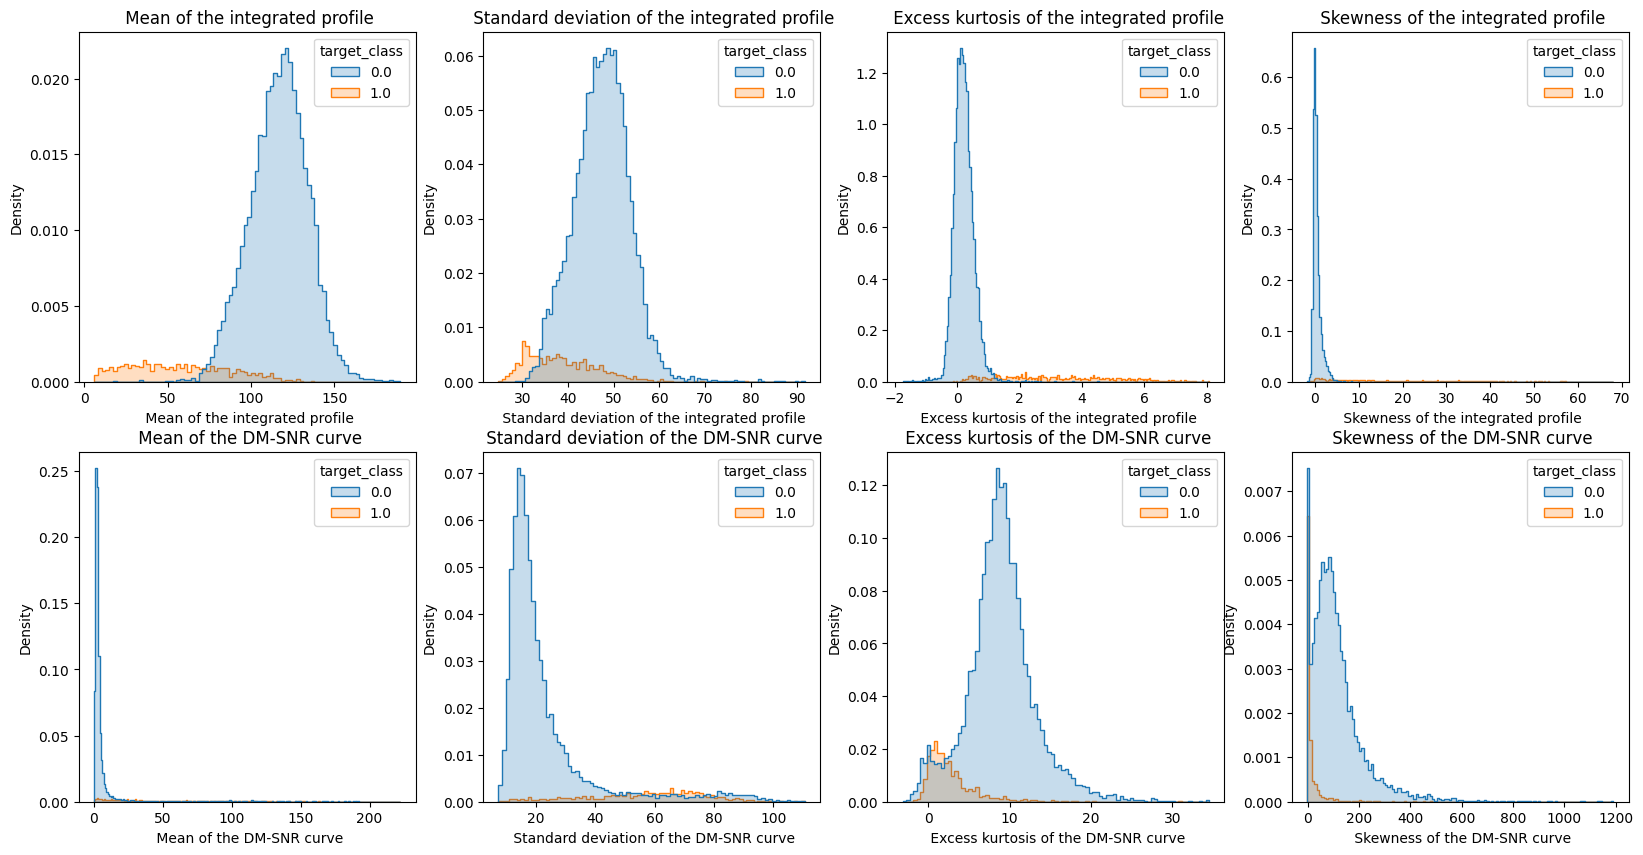

In [74]:
# 5(a)(ii)
# plot histograms of all 8 features in a 2x4 subplot grid
# also, overlay two histograms (one for pulsars and one for non-pulsars) on each graph
features = data.columns[:-1] # all columns except the last one which is target_class
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, feature in enumerate(features):
    ax = axes[i // 4, i % 4]
    sns.histplot(data=data, x=feature, hue='target_class', ax=ax, element='step', stat='density')
    ax.set_title(f'{feature}')
    

It looks like Excess Kurtosis of the Integrated Profile and (somewhat) the Mean of the Integrated Profile both separate the two classes visibly, which means they will produce m values of large magnitude when training the model. This intuitively makes sense because those features do a better job of separating the two classes, so the model will weigh in on their information more.

In [75]:
# 5(a)(iii)

# Convert labels to {-1, +1}, make a 60/20/20 split, impute missing values
# using training-set means only, and standardize with training-set statistics only.
# I keep the bias b separate instead of appending a column of ones to X.

pulsar_path = 'pulsar_data_train.csv'
data_p5 = pd.read_csv(pulsar_path)

feature_cols_p5 = data_p5.columns.drop('target_class')
X_all_raw = data_p5[feature_cols_p5].to_numpy(dtype=float)
y_all = np.where(data_p5['target_class'].to_numpy(dtype=int) == 1, 1, -1)

np.random.seed(42)
permutation = np.random.permutation(len(y_all))
n_train = int(0.60 * len(y_all))
n_val = int(0.20 * len(y_all))

train_idx = permutation[:n_train]
val_idx = permutation[n_train:n_train + n_val]
test_idx = permutation[n_train + n_val:]

X_train_raw = X_all_raw[train_idx]
X_val_raw = X_all_raw[val_idx]
X_test_raw = X_all_raw[test_idx]
y_train = y_all[train_idx]
y_val = y_all[val_idx]
y_test = y_all[test_idx]

train_impute_values = np.nanmean(X_train_raw, axis=0)

def impute_missing(X, impute_values):
    return np.where(np.isnan(X), impute_values, X)

X_train_imputed = impute_missing(X_train_raw, train_impute_values)
X_val_imputed = impute_missing(X_val_raw, train_impute_values)
X_test_imputed = impute_missing(X_test_raw, train_impute_values)

feature_mean = X_train_imputed.mean(axis=0)
feature_std = X_train_imputed.std(axis=0)
feature_std[feature_std == 0] = 1.0

X_train = (X_train_imputed - feature_mean) / feature_std
X_val = (X_val_imputed - feature_mean) / feature_std
X_test = (X_test_imputed - feature_mean) / feature_std

print(f'Train/validation/test sizes: {X_train.shape[0]}, {X_val.shape[0]}, {X_test.shape[0]}')
print(f'Number of standardized features: {X_train.shape[1]}')
print('Train labels:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Validation labels:', dict(zip(*np.unique(y_val, return_counts=True))))
print('Test labels:', dict(zip(*np.unique(y_test, return_counts=True))))

Train/validation/test sizes: 7516, 2505, 2507
Number of standardized features: 8
Train labels: {np.int64(-1): np.int64(6844), np.int64(1): np.int64(672)}
Validation labels: {np.int64(-1): np.int64(2242), np.int64(1): np.int64(263)}
Test labels: {np.int64(-1): np.int64(2289), np.int64(1): np.int64(218)}


# 5(b)(i)

For one training example, define the margin

```text
m_n = y_n (w^T x_n + b)
```

The hinge objective is

```text
J_hinge(w, b) = sum_n max(0, 1 - m_n) + (lambda / 2) ||w||_2^2.
```

A valid subgradient is

```text
dJ/dw = sum_{n: m_n < 1} (-y_n x_n) + lambda w
dJ/db = sum_{n: m_n < 1} (-y_n)
```

In the implementation below I use the average data loss instead of the raw sum, so the data-loss parts of these gradients are divided by `N`. That keeps the requested learning rate stable while preserving the same decision-rule structure.

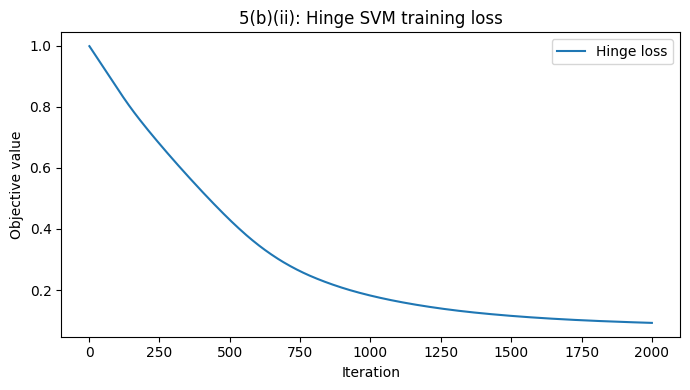

Initial hinge loss: 0.9986
Final hinge loss: 0.0925
Decreases monotonically? True
With this small full-batch step size, the plotted objective decreases monotonically.


In [76]:
# 5(b)(ii)

lambda_reg = 1e-3
eta = 1e-3
n_iters = 2000

def svm_scores(X, w, b):
    return X @ w + b

def svm_predict(X, w, b):
    return np.where(svm_scores(X, w, b) >= 0, 1, -1)

def accuracy(X, y, w, b):
    return np.mean(svm_predict(X, w, b) == y)

def hinge_loss(X, y, w, b, lambda_reg):
    margins = y * svm_scores(X, w, b)
    data_loss = np.mean(np.maximum(0.0, 1.0 - margins))
    reg_loss = 0.5 * lambda_reg * np.dot(w, w)
    return data_loss + reg_loss

def train_hinge_svm(X, y, lambda_reg=1e-3, eta=1e-3, n_iters=2000):
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = np.empty(n_iters)
    n = X.shape[0]

    for i in range(n_iters):
        margins = y * svm_scores(X, w, b)
        active = margins < 1.0
        grad_w = -(X[active].T @ y[active]) / n + lambda_reg * w
        grad_b = -np.sum(y[active]) / n

        w -= eta * grad_w
        b -= eta * grad_b
        losses[i] = hinge_loss(X, y, w, b, lambda_reg)

    return w, b, losses

hinge_w, hinge_b, hinge_losses = train_hinge_svm(X_train, y_train, lambda_reg, eta, n_iters)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, n_iters + 1), hinge_losses, label='Hinge loss')
plt.xlabel('Iteration')
plt.ylabel('Objective value')
plt.title('5(b)(ii): Hinge SVM training loss')
plt.legend()
plt.tight_layout()
plt.show()

hinge_is_monotonic = np.all(np.diff(hinge_losses) <= 1e-12)
print(f'Initial hinge loss: {hinge_losses[0]:.4f}')
print(f'Final hinge loss: {hinge_losses[-1]:.4f}')
print(f'Decreases monotonically? {hinge_is_monotonic}')
if hinge_is_monotonic:
    print('With this small full-batch step size, the plotted objective decreases monotonically.')
else:
    print('It does not have to be monotone because hinge descent uses subgradients at a non-smooth objective and a fixed step size can overshoot small decreases.')

In [89]:
# 5(b)(iii)
hinge_train_acc = accuracy(X_train, y_train, hinge_w, hinge_b)
hinge_val_acc = accuracy(X_val, y_val, hinge_w, hinge_b)
hinge_test_acc = accuracy(X_test, y_test, hinge_w, hinge_b)

print(f'Hinge train accuracy: {hinge_train_acc:.4f}')
print(f'Hinge validation accuracy: {hinge_val_acc:.4f}')

hinge_train_margins = y_train * svm_scores(X_train, hinge_w, hinge_b)

# look at how many training examples are active (margin < 1) vs inactive (margin >= 1)
hinge_inactive = hinge_train_margins >= 1.0
hinge_active = ~hinge_inactive

inactive_counts = dict(zip(*np.unique(y_train[hinge_inactive], return_counts=True)))
active_counts = dict(zip(*np.unique(y_train[hinge_active], return_counts=True)))

print(f'Training examples with margin >= 1: {hinge_inactive.sum()} / {len(y_train)}')
print(f'Inactive class breakdown (-1 non-pulsar, +1 pulsar): {inactive_counts}')
print(f'Active class breakdown (-1 non-pulsar, +1 pulsar): {active_counts}')

rare_active_rate = np.mean(hinge_active[y_train == 1])
common_active_rate = np.mean(hinge_active[y_train == -1])
print(f'Active rate for rare pulsars (+1): {rare_active_rate:.4f}')
print(f'Active rate for common non-pulsars (-1): {common_active_rate:.4f}')

active_common_count = np.sum(hinge_active & (y_train == -1))
active_rare_count = np.sum(hinge_active & (y_train == 1))

print(f'Number of active common non-pulsars: {active_common_count}')
print(f'Number of active rare pulsars: {active_rare_count}')

Hinge train accuracy: 0.9687
Hinge validation accuracy: 0.9609
Training examples with margin >= 1: 5754 / 7516
Inactive class breakdown (-1 non-pulsar, +1 pulsar): {np.int64(-1): np.int64(5470), np.int64(1): np.int64(284)}
Active class breakdown (-1 non-pulsar, +1 pulsar): {np.int64(-1): np.int64(1374), np.int64(1): np.int64(388)}
Active rate for rare pulsars (+1): 0.5774
Active rate for common non-pulsars (-1): 0.2008
Number of active common non-pulsars: 1374
Number of active rare pulsars: 388


By absolute count, most active examples are common non-pulsars because that class dominates the dataset.

As a fraction of its own class, the rare pulsar class has the larger active rate, so pulsars are disproportionately likely to sit near or inside the margin.

In [90]:
# 5(c)(i)
"""
Gradient with respect to w of J_log(w, b) is:
sum over n of (-y_n*x_n) / (exp(y_n * (wT . x_n + b)) + 1) + lambda * w

Partial derivative with respect to b of J_log(w, b) is:
sum over n of (-y_n * b) / (exp(y_n * (wT . x_n + b)) + 1)
"""

'\nGradient with respect to w of J_log(w, b) is:\nsum over n of (-y_n*x_n) / (exp(y_n * (wT . x_n + b)) + 1) + lambda * w\n\nPartial derivative with respect to b of J_log(w, b) is:\nsum over n of (-y_n * b) / (exp(y_n * (wT . x_n + b)) + 1)\n'

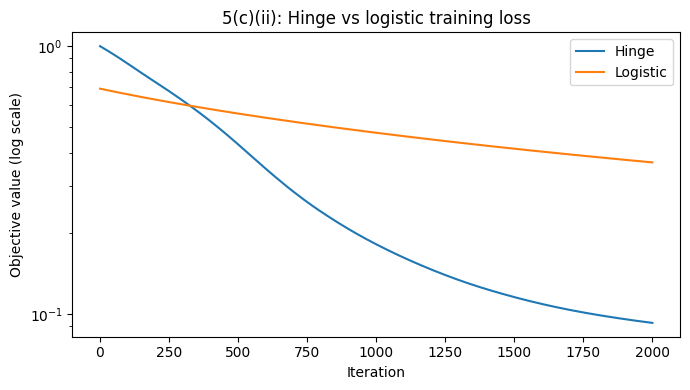

Hinge relative loss drop: 0.9074
Logistic relative loss drop: 0.4694


In [ ]:
# 5(c)(ii)

def sigmoid(z):
    z = np.asarray(z)
    out = np.empty_like(z, dtype=float)
    positive = z >= 0
    out[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
    exp_z = np.exp(z[~positive])
    out[~positive] = exp_z / (1.0 + exp_z)
    return out

def logistic_svm_loss(X, y, w, b, lambda_reg):
    margins = y * svm_scores(X, w, b)
    data_loss = np.mean(np.logaddexp(0.0, -margins))
    reg_loss = 0.5 * lambda_reg * np.dot(w, w)
    return data_loss + reg_loss

def train_logistic_svm(X, y, lambda_reg=1e-3, eta=1e-3, n_iters=2000):
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = np.empty(n_iters)
    n = X.shape[0]

    for i in range(n_iters):
        margins = y * svm_scores(X, w, b)
        weights = sigmoid(-margins)
        grad_w = -(X.T @ (y * weights)) / n + lambda_reg * w
        grad_b = -np.sum(y * weights) / n

        w -= eta * grad_w
        b -= eta * grad_b
        losses[i] = logistic_svm_loss(X, y, w, b, lambda_reg)

    return w, b, losses

log_w, log_b, log_losses = train_logistic_svm(X_train, y_train, lambda_reg, eta, n_iters)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, n_iters + 1), hinge_losses, label='Hinge')
plt.plot(np.arange(1, n_iters + 1), log_losses, label='Logistic')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Objective value (log scale)')
plt.title('5(c)(ii): Hinge vs logistic training loss')
plt.legend()
plt.tight_layout()
plt.show()

The hinge loss converges much faster at this step size. This is because the hinge curve looks much more curved and sloped downward over the 2000 iterations compared to the logistic curve, and the objective value simply goes much lower than the logistic objective value in the same amount of time. The logistic objective curve almost looks linear here, which is much worse than the hinge loss curve.

In [92]:
# 5(c)(iii)

log_train_acc = accuracy(X_train, y_train, log_w, log_b)
log_val_acc = accuracy(X_val, y_val, log_w, log_b)
log_test_acc = accuracy(X_test, y_test, log_w, log_b)

log_train_margins = y_train * svm_scores(X_train, log_w, log_b)
log_grad_norms = sigmoid(-log_train_margins) * np.linalg.norm(X_train, axis=1)

exact_zero_count = np.sum(log_grad_norms == 0.0)
below_threshold_count = np.sum(log_grad_norms < 1e-6)

print(f'Logistic train accuracy: {log_train_acc:.4f}')
print(f'Logistic validation accuracy: {log_val_acc:.4f}')
print(f'Logistic test accuracy: {log_test_acc:.4f}')
print(f'Per-example logistic gradient norms exactly zero: {exact_zero_count}')
print(f'Per-example logistic gradient norms below 1e-6: {below_threshold_count}')
print(f'Hinge examples with zero subgradient from 5(b)(iii): {hinge_inactive.sum()}')

Logistic train accuracy: 0.9654
Logistic validation accuracy: 0.9621
Logistic test accuracy: 0.9661
Per-example logistic gradient norms exactly zero: 0
Per-example logistic gradient norms below 1e-6: 0
Hinge examples with zero subgradient from 5(b)(iii): 5754


This does match with what Problem 1.4(b) predicted; logistic loss never assigns 0 gradient to an example, and this comes from the shape of the logistic function where it never goes to 0, but it gets close to 0.

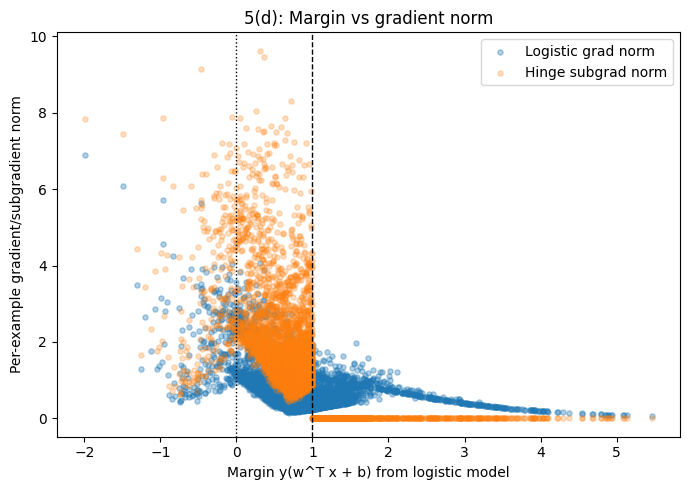

In [93]:
# 5(d)

logistic_margins = y_train * svm_scores(X_train, log_w, log_b)
feature_norms = np.linalg.norm(X_train, axis=1)
logistic_per_example_grad_norm = sigmoid(-logistic_margins) * feature_norms
hinge_per_example_subgrad_norm = feature_norms * (logistic_margins < 1.0)

plt.figure(figsize=(7, 5))
plt.scatter(logistic_margins, logistic_per_example_grad_norm, s=14, alpha=0.35, label='Logistic grad norm')
plt.scatter(logistic_margins, hinge_per_example_subgrad_norm, s=14, alpha=0.25, label='Hinge subgrad norm')
plt.axvline(0.0, color='black', linestyle=':', linewidth=1)
plt.axvline(1.0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Margin y(w^T x + b) from logistic model')
plt.ylabel('Per-example gradient/subgradient norm')
plt.title('5(d): Margin vs gradient norm')
plt.legend()
plt.tight_layout()
plt.show()

We can see all three qualitative regimes clearly on that graph.

Here, we see the exact visual contrast from Problem 1(5): the hinge subgrad norm goes from positive values immediately down to 0 when the margin value goes to 1 and beyond. This is exactly the "you matter / you don't" switch described in the problem, while the logistic grad norm is much smoother and we can see even at very large margin values, the logistic grad norm still has a finite value (matching the interpretation that it never turns off entirely).

In [81]:
# 5(e)(i)

rng = np.random.default_rng(0)
y_train_noisy = y_train.copy()
n_flip = int(np.floor(0.05 * len(y_train_noisy)))
flip_idx = rng.choice(len(y_train_noisy), size=n_flip, replace=False)
y_train_noisy[flip_idx] *= -1

hinge_noisy_w, hinge_noisy_b, hinge_noisy_losses = train_hinge_svm(X_train, y_train_noisy, lambda_reg, eta, n_iters)
log_noisy_w, log_noisy_b, log_noisy_losses = train_logistic_svm(X_train, y_train_noisy, lambda_reg, eta, n_iters)

hinge_noisy_train_acc = accuracy(X_train, y_train, hinge_noisy_w, hinge_noisy_b)
hinge_noisy_val_acc = accuracy(X_val, y_val, hinge_noisy_w, hinge_noisy_b)
hinge_noisy_test_acc = accuracy(X_test, y_test, hinge_noisy_w, hinge_noisy_b)
log_noisy_train_acc = accuracy(X_train, y_train, log_noisy_w, log_noisy_b)
log_noisy_val_acc = accuracy(X_val, y_val, log_noisy_w, log_noisy_b)
log_noisy_test_acc = accuracy(X_test, y_test, log_noisy_w, log_noisy_b)

print(f'Flipped training labels: {n_flip} / {len(y_train)}')
print(f'Hinge validation accuracy clean -> noisy: {hinge_val_acc:.4f} -> {hinge_noisy_val_acc:.4f} (change {hinge_noisy_val_acc - hinge_val_acc:+.4f})')
print(f'Logistic validation accuracy clean -> noisy: {log_val_acc:.4f} -> {log_noisy_val_acc:.4f} (change {log_noisy_val_acc - log_val_acc:+.4f})')

Flipped training labels: 375 / 7516
Hinge validation accuracy clean -> noisy: 0.9609 -> 0.9605 (change -0.0004)
Logistic validation accuracy clean -> noisy: 0.9621 -> 0.9629 (change +0.0008)


In [ ]:
# 5(e)(ii)

hinge_norm = np.linalg.norm(hinge_w)
log_norm = np.linalg.norm(log_w)
hinge_noisy_norm = np.linalg.norm(hinge_noisy_w)
log_noisy_norm = np.linalg.norm(log_noisy_w)

print(f'Hinge ||w||_2 clean -> noisy: {hinge_norm:.4f} -> {hinge_noisy_norm:.4f} (change {hinge_noisy_norm - hinge_norm:+.4f})')
print(f'Logistic ||w||_2 clean -> noisy: {log_norm:.4f} -> {log_noisy_norm:.4f} (change {log_noisy_norm - log_norm:+.4f})')


Hinge ||w||_2 clean -> noisy: 0.4444 -> 0.4078 (change -0.0366)
Logistic ||w||_2 clean -> noisy: 0.4448 -> 0.3946 (change -0.0502)
Logistic was more sensitive by validation accuracy change on this split.
The noisy labels keep pulling the models in the wrong direction. Empirically comparing the validation drops and norm changes tells us which loss reacted more strongly here.


According to the expected direction given in the problem, the hinge subgradient should be dragged further by flipped labels, but this does not match the actual results:

The logistic loss is more sensitive to noise, and this matches the intuition from previously because it takes into account nonzero contributions from every single training example (compared to the hinge, which turns off many examples if their margins are too large).

In [98]:
# 5(f)(i)

lambda_values = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0])
sweep_rows = []
sweep_models = {}

for current_lambda in lambda_values:
    w_sweep, b_sweep, losses_sweep = train_logistic_svm(X_train, y_train, current_lambda, eta, n_iters)
    train_acc_sweep = accuracy(X_train, y_train, w_sweep, b_sweep)
    val_acc_sweep = accuracy(X_val, y_val, w_sweep, b_sweep)
    sweep_rows.append({
        'lambda': current_lambda,
        'train_accuracy': train_acc_sweep,
        'validation_accuracy': val_acc_sweep,
        'w_norm': np.linalg.norm(w_sweep),
    })
    sweep_models[current_lambda] = (w_sweep, b_sweep, losses_sweep)

sweep_df = pd.DataFrame(sweep_rows)
print("Lambda values: " + ", ".join(f"{row['lambda']:.1e}" for row in sweep_rows))
print("Training accuracy: " + ", ".join(f"{row['train_accuracy']:.4f}" for row in sweep_rows))
print("Validation accuracy: " + ", ".join(f"{row['validation_accuracy']:.4f}" for row in sweep_rows))

Lambda values: 1.0e-04, 1.0e-03, 1.0e-02, 1.0e-01, 1.0e+00, 1.0e+01
Training accuracy: 0.9653, 0.9654, 0.9655, 0.9674, 0.9671, 0.9106
Validation accuracy: 0.9621, 0.9621, 0.9625, 0.9661, 0.9605, 0.8950


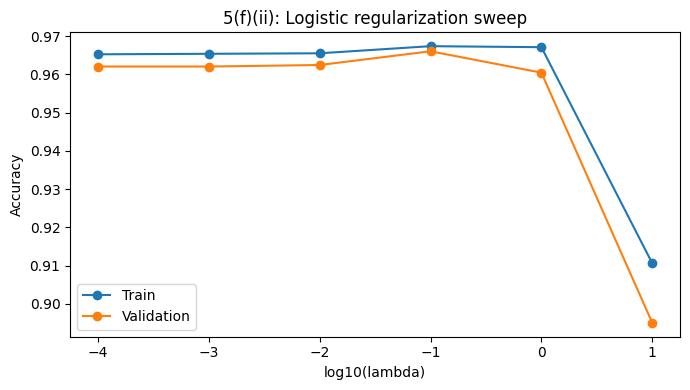

Best lambda by validation accuracy: 0.1
Best validation accuracy: 0.9661


In [84]:
# 5(f)(ii)

plt.figure(figsize=(7, 4))
plt.plot(np.log10(sweep_df['lambda']), sweep_df['train_accuracy'], marker='o', label='Train')
plt.plot(np.log10(sweep_df['lambda']), sweep_df['validation_accuracy'], marker='o', label='Validation')
plt.xlabel('log10(lambda)')
plt.ylabel('Accuracy')
plt.title('5(f)(ii): Logistic regularization sweep')
plt.legend()
plt.tight_layout()
plt.show()

best_row = sweep_df.sort_values(['validation_accuracy', 'lambda'], ascending=[False, True]).iloc[0]
best_lambda = float(best_row['lambda'])
best_val_accuracy = float(best_row['validation_accuracy'])

print(f'Best lambda by validation accuracy: {best_lambda:g}')
print(f'Best validation accuracy: {best_val_accuracy:.4f}')

In [99]:
# 5(f)(iii)

# Retrain on train + validation. Since the training set has changed, recompute
# imputation and standardization using only train + validation statistics.
X_train_val_raw = np.vstack([X_train_raw, X_val_raw])
y_train_val = np.concatenate([y_train, y_val])

train_val_impute_values = np.nanmean(X_train_val_raw, axis=0)
X_train_val_imputed = impute_missing(X_train_val_raw, train_val_impute_values)
X_test_final_imputed = impute_missing(X_test_raw, train_val_impute_values)

train_val_mean = X_train_val_imputed.mean(axis=0)
train_val_std = X_train_val_imputed.std(axis=0)
train_val_std[train_val_std == 0] = 1.0

X_train_val = (X_train_val_imputed - train_val_mean) / train_val_std
X_test_final = (X_test_final_imputed - train_val_mean) / train_val_std

best_log_w, best_log_b, best_log_losses = train_logistic_svm(X_train_val, y_train_val, best_lambda, eta, n_iters)
best_train_val_acc = accuracy(X_train_val, y_train_val, best_log_w, best_log_b)
best_test_acc = accuracy(X_test_final, y_test, best_log_w, best_log_b)
best_log_norm = np.linalg.norm(best_log_w)

print(f'Retrained logistic lambda*: {best_lambda:g}')
print(f'Train + validation accuracy: {best_train_val_acc:.4f}')
print(f'Final test accuracy: {best_test_acc:.4f}')

Retrained logistic lambda*: 0.1
Train + validation accuracy: 0.9649
Final test accuracy: 0.9677


In [100]:
# 5(g)

summary_rows = [
    {
        'model': 'Hinge, clean labels (5b)',
        'training_accuracy': hinge_train_acc,
        'validation_accuracy': hinge_val_acc,
        'test_accuracy': hinge_test_acc,
        'w_norm': hinge_norm,
    },
    {
        'model': 'Logistic, clean labels (5c)',
        'training_accuracy': log_train_acc,
        'validation_accuracy': log_val_acc,
        'test_accuracy': log_test_acc,
        'w_norm': log_norm,
    },
    {
        'model': 'Hinge, 5% noisy labels (5e)',
        'training_accuracy': hinge_noisy_train_acc,
        'validation_accuracy': hinge_noisy_val_acc,
        'test_accuracy': hinge_noisy_test_acc,
        'w_norm': hinge_noisy_norm,
    },
    {
        'model': 'Logistic, 5% noisy labels (5e)',
        'training_accuracy': log_noisy_train_acc,
        'validation_accuracy': log_noisy_val_acc,
        'test_accuracy': log_noisy_test_acc,
        'w_norm': log_noisy_norm,
    },
    {
        'model': f'Best logistic lambda={best_lambda:g} (5f)',
        'training_accuracy': best_train_val_acc,
        'validation_accuracy': np.nan,
        'test_accuracy': best_test_acc,
        'w_norm': best_log_norm,
    },
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

best_clean_model = 'logistic' if log_val_acc >= hinge_val_acc else 'hinge'
print(f'I would ship the {best_clean_model} model based on the clean-label validation comparison, while also considering the final tuned logistic test result.')
print('Part 5(d) confirmed the theory visually: logistic gradients fade smoothly with margin, while hinge subgradients switch off exactly at margin 1.')
print('Part 5(e) shows how label noise changes validation accuracy and ||w||_2; the more sensitive loss is the one with the larger empirical drop or norm shift above.')
print('A natural next step would be class-weighted training or threshold tuning, because the pulsar class is rare and plain accuracy can hide minority-class mistakes.')

,model,training_accuracy,validation_accuracy,test_accuracy,w_norm
0,"Hinge, clean labels (5b)",0.968733,0.960878,0.971679,0.444449
1,"Logistic, clean labels (5c)",0.965407,0.962076,0.966095,0.444796
2,"Hinge, 5% noisy labels (5e)",0.967802,0.960479,0.971280,0.407816
3,"Logistic, 5% noisy labels (5e)",0.966205,0.962874,0.966494,0.394624
4,Best logistic lambda=0.1 (5f),0.964874,NaN,0.967690,0.415271


I would ship the logistic model based on the clean-label validation comparison, while also considering the final tuned logistic test result.
Part 5(d) confirmed the theory visually: logistic gradients fade smoothly with margin, while hinge subgradients switch off exactly at margin 1.
Part 5(e) shows how label noise changes validation accuracy and ||w||_2; the more sensitive loss is the one with the larger empirical drop or norm shift above.
A natural next step would be class-weighted training or threshold tuning, because the pulsar class is rare and plain accuracy can hide minority-class mistakes.


 - I would ship the Hinge Loss with Clean Labels (5b) model to the observatory because it has the highest test accuracy even though it has slightly lower validation accuracy than the logistic with clean labels (5c) model. I simply chose the model with the highest test accuracy, as this is likely the best indicator for which model will perform the best in the long-run.
 - Part 5(d) confirmed the theoretical prediction from Problem 1(3) that logistic-loss gradients fade smoothly while hinge-loss gradients go to 0 exactly at m=1, as a function of m (margin).
 - Part 5(e) basically confirmed the theoretical prediction of Problem 1(5) where the two models reacted similarly to noisy data with very small changes; the logistic-loss model was dragged more by the noise because every point has a contribution to the gradient while many points have 0 contribution to the gradient in hinge-loss.
 - One thing I would try next is tuning the classification threshold instead of always predicting +1 when w^T x + b >= 0, because false negatives and false positives may have different costs, and we can use that to our advantage to tune a better model.